In [1]:
import warnings
import torch

# Suppress all warnings
warnings.filterwarnings("ignore")

In [2]:
import torch

def check_cuda():
    print(f"PyTorch version: {torch.__version__}")
    
    # Check if CUDA is available
    cuda_available = torch.cuda.is_available()
    print(f"CUDA available: {cuda_available}")
    
    if cuda_available:
        # Get the number of available GPUs
        device_count = torch.cuda.device_count()
        print(f"Number of GPUs detected: {device_count}")
        
        # Get the name of the current GPU
        current_device = torch.cuda.current_device()
        gpu_name = torch.cuda.get_device_name(current_device)
        print(f"Current GPU Device ID: {current_device}")
        print(f"GPU Name: {gpu_name}")
        
    else:
        print("\nPyTorch is currently running on the CPU.")
        print("If you have an NVIDIA GPU, make sure you installed the PyTorch version compiled with CUDA.")

check_cuda()

PyTorch version: 2.6.0+cu124
CUDA available: True
Number of GPUs detected: 1
Current GPU Device ID: 0
GPU Name: NVIDIA RTX 2000 Ada Generation Laptop GPU


In [ ]:
import torch
from diffusers import DiffusionPipeline

multi_view_diffusion_pipeline = DiffusionPipeline.from_pretrained(
    "dylanebert/multi-view-diffusion",
    custom_pipeline="dylanebert/multi-view-diffusion",
    torch_dtype=torch.float16,
    trust_remote_code=True,
).to("cuda")

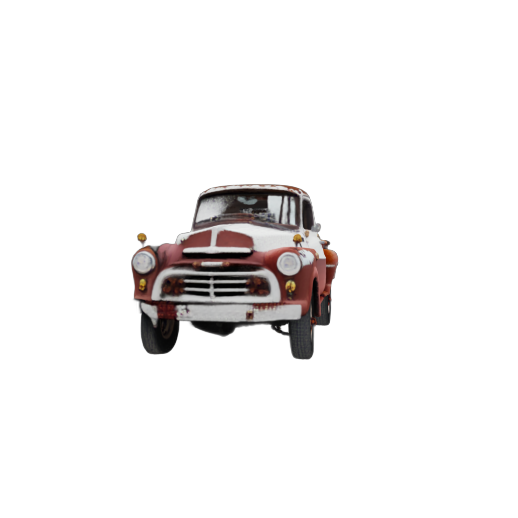

In [ ]:
from PIL import Image
import numpy as np
from rembg import remove

image_path = "../img/image.png" 
image = Image.open(image_path)

# Remove the background (this outputs an RGBA image with transparency)
image_rgba = remove(image)

# For Gaussian Splatting / Diffusion, a clean white background is often preferred over transparency
white_bg = Image.new("RGBA", image_rgba.size, "WHITE")
white_bg.paste(image_rgba, (0, 0), image_rgba)

# Convert to RGB
image = white_bg.convert("RGB")

image

100%|██████████| 30/30 [00:04<00:00,  6.66it/s]


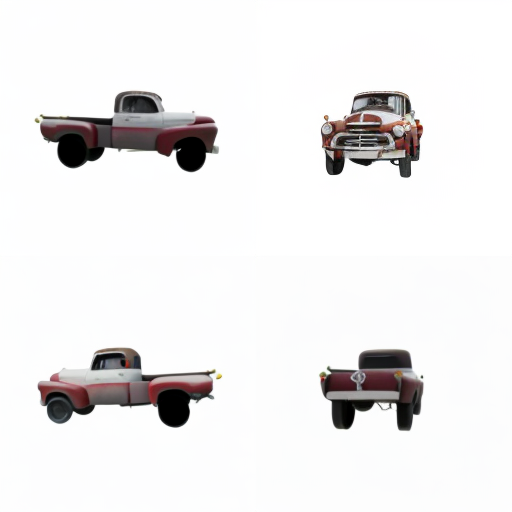

In [10]:
import numpy as np

def create_image_grid(images):
    images = [Image.fromarray((img * 255).astype("uint8")) for img in images]

    width, height = images[0].size
    grid_img = Image.new("RGB", (2 * width, 2 * height))

    grid_img.paste(images[0], (0, 0))
    grid_img.paste(images[1], (width, 0))
    grid_img.paste(images[2], (0, height))
    grid_img.paste(images[3], (width, height))

    return grid_img

# prepare the image by converting it to a normalized numpy array
image = np.array(image, dtype=np.float32) / 255.0
images = multi_view_diffusion_pipeline(
    "",                         # text prompt input
    image,                      # source 2D image
    guidance_scale=5,           # Classifier-Free Guidance (CFG) -> control how much creative freedom the model has
    num_inference_steps=30,     # the number of denoising steps
    elevation=0                 # specify the camera's vertical angle (in degrees) relative to the object for the generated views
)

create_image_grid(images)

In [ ]:
import gradio as gr

def run(image):
  image = np.array(image, dtype=np.float32) / 255.0
  images = multi_view_diffusion_pipeline("", image, guidance_scale=5, num_inference_steps=30, elevation=0)

  images = [Image.fromarray((img * 255).astype("uint8")) for img in images]

  width, height = images[0].size
  grid_img = Image.new("RGB", (2 * width, 2 * height))

  grid_img.paste(images[0], (0, 0))
  grid_img.paste(images[1], (width, 0))
  grid_img.paste(images[2], (0, height))
  grid_img.paste(images[3], (width, height))

  return grid_img

demo = gr.Interface(fn=run, inputs="image", outputs="image")
demo.launch()